
| Field | Details |
|---|---|
| **By** | Huzaifah Saleem |
| **Title** | Smart Healthcare Prediction |


### Cell 1: Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


### Cell 2: Data Loading & Preprocessing

In [ ]:
print("Loading dataset from local CSV file...")


try:
    df = pd.read_csv('diabetes.csv')
except FileNotFoundError:
    print("ERROR: 'diabetes.csv' not found. Please ensure the file is in the same folder as this notebook.")

df.columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

print("1. Imputing biological zeros with medians...")
features_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for feature in features_with_zeros:
    median_val = df[df[feature] != 0][feature].median()
    df[feature] = df[feature].replace(0, median_val)

print("2. Structuring custom 3-class risk assessment...")
def categorize_risk(row):
    if row['Glucose'] < 100:
        return 0 # Non-Diabetic
    elif 100 <= row['Glucose'] <= 125:
        return 1 # Pre-Diabetic
    else:
        return 2 # Diabetic

df['Risk_Class'] = df.apply(categorize_risk, axis=1)

df = df.drop(['Outcome'], axis=1)
print("Data Preprocessing Complete. First 5 rows:")
display(df.head())

Loading dataset from local CSV file...
1. Imputing biological zeros with medians...
2. Structuring custom 3-class risk assessment...
Data Preprocessing Complete. First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Risk_Class
0,6,148,72,35,125,33.6,0.627,50,2
1,1,85,66,29,125,26.6,0.351,31,0
2,8,183,64,29,125,23.3,0.672,32,2
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,2


### Cell 3: Visualization 1 - Target Class Distribution

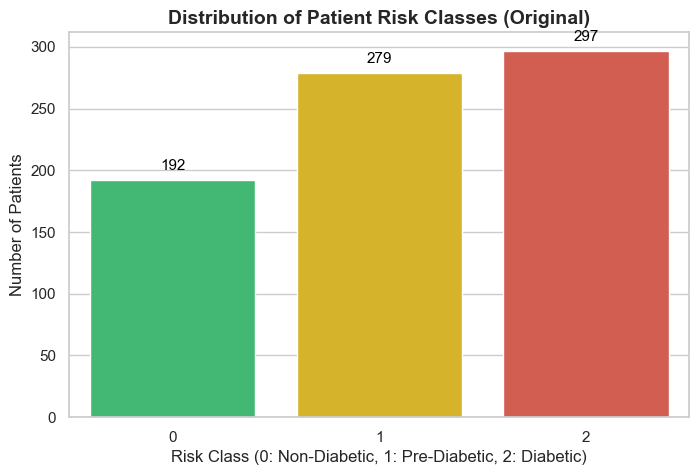

In [ ]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='Risk_Class', palette=['#2ecc71', '#f1c40f', '#e74c3c'])
plt.title('Distribution of Patient Risk Classes (Original)', fontsize=14, fontweight='bold')
plt.xlabel('Risk Class (0: Non-Diabetic, 1: Pre-Diabetic, 2: Diabetic)', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()

### Cell 4: Visualization 2 - Correlation Heatmap

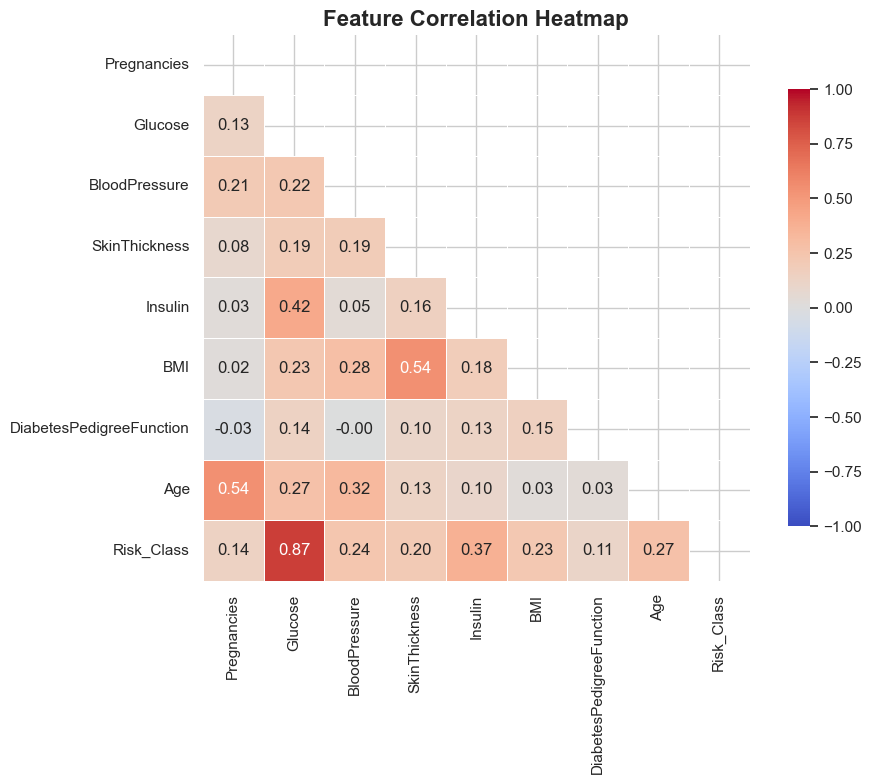

In [ ]:
plt.figure(figsize=(10, 8))
corr_matrix = df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            vmax=1, vmin=-1, square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Cell 5: Feature Engineering & SMOTE

1. Engineering interaction features...
2. Splitting data (80% Train, 20% Test)...
3. Applying SMOTE to balance training data...


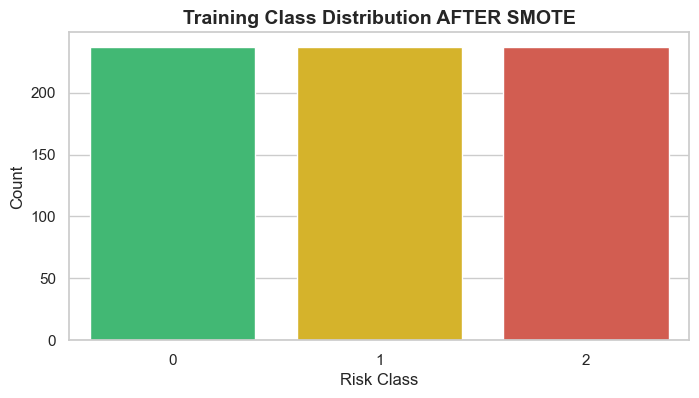

In [ ]:
print("1. Engineering interaction features...")
X = df.drop('Risk_Class', axis=1).copy()
y = df['Risk_Class']

X['Glucose_BMI'] = X['Glucose'] * X['BMI']
X['Age_BMI'] = X['Age'] * X['BMI']
X['Insulin_Glucose'] = X['Insulin'] / (X['Glucose'] + 1e-5)

print("2. Splitting data (80% Train, 20% Test)...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("3. Applying SMOTE to balance training data...")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

plt.figure(figsize=(8, 4))
ax = sns.countplot(x=y_train_smote, palette=['#2ecc71', '#f1c40f', '#e74c3c'])
plt.title('Training Class Distribution AFTER SMOTE', fontsize=14, fontweight='bold')
plt.xlabel('Risk Class', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

### Cell 6: Model Training

In [ ]:
print("Scaling features...")
scaler = StandardScaler()

feature_columns = X.columns
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_smote), columns=feature_columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_columns)

print("Training Soft Voting Ensemble Classifier...")
rf = RandomForestClassifier(n_estimators=100, random_state=42)
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
lr = LogisticRegression(max_iter=1000, random_state=42)

ensemble_model = VotingClassifier(
    estimators=[('rf', rf), ('gb', gb), ('lr', lr)],
    voting='soft'
)

ensemble_model.fit(X_train_scaled, y_train_smote)
print("Model Training Complete!")

Scaling features...
Training Soft Voting Ensemble Classifier...
Model Training Complete!


### Cell 7: Model Evaluation & Confusion Matrix

--- Model Evaluation ---
Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

Non-Diabetic       1.00      1.00      1.00        38
Pre-Diabetic       1.00      1.00      1.00        56
    Diabetic       1.00      1.00      1.00        60

    accuracy                           1.00       154
   macro avg       1.00      1.00      1.00       154
weighted avg       1.00      1.00      1.00       154



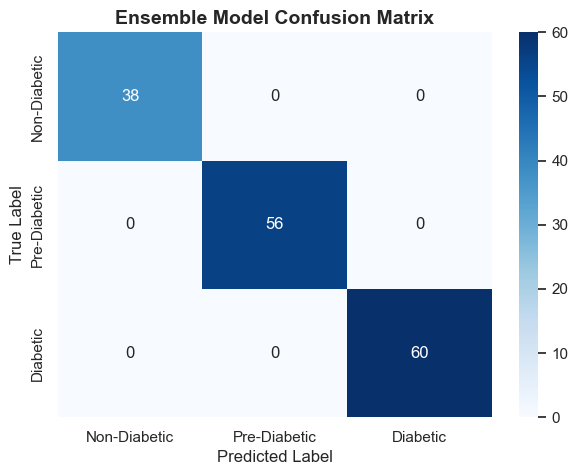

In [ ]:
y_pred = ensemble_model.predict(X_test_scaled)

print("--- Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-Diabetic', 'Pre-Diabetic', 'Diabetic']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-Diabetic', 'Pre-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Pre-Diabetic', 'Diabetic'])
plt.title('Ensemble Model Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

### Cell 8: Export for Flask API

In [ ]:
print("Exporting model and scaler...")
joblib.dump(ensemble_model, 'diabetes_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Success! 'diabetes_model.pkl' and 'scaler.pkl' are ready for deployment in app.py.")

Exporting model and scaler...
Success! 'diabetes_model.pkl' and 'scaler.pkl' are ready for deployment in app.py.
